In [316]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [317]:
df = pd.read_csv('tvmarketing.csv')
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [318]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [319]:
df.describe()

,TV,Sales
count,200.000000,200.000000
mean,147.042500,14.022500
std,85.854236,5.217457
min,0.700000,1.600000
25%,74.375000,10.375000
50%,149.750000,12.900000
75%,218.825000,17.400000
max,296.400000,27.000000


In [320]:
df.isna().sum()

TV       0
Sales    0
dtype: int64

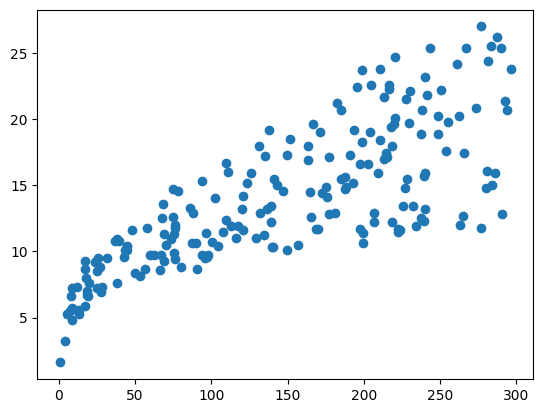

In [321]:
plt.scatter(x= df['TV'],y = df['Sales'])

(array([26., 15., 21., 18., 19., 17., 22., 26., 20., 16.]),
 array([  0.7 ,  30.27,  59.84,  89.41, 118.98, 148.55, 178.12, 207.69,
        237.26, 266.83, 296.4 ]),
 <BarContainer object of 10 artists>)

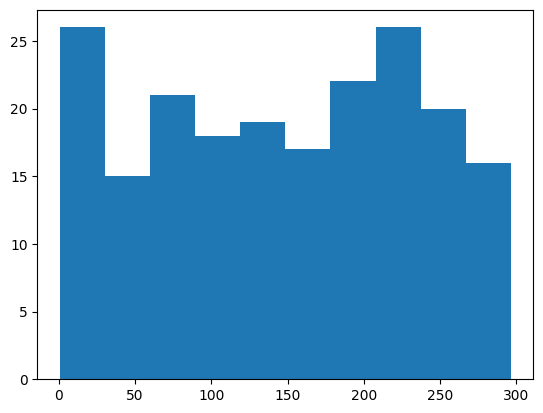

In [322]:
plt.hist(df['TV'])

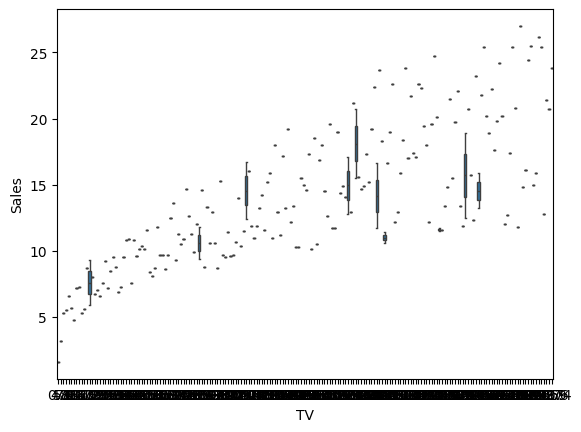

In [323]:
sns.boxplot(x = 'TV',y = 'Sales',data= df)
plt.show()

In [324]:
X_train,X_test,Y_train,Y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [325]:
# check the shape of all the variables
for i in X_train,X_test,Y_train,Y_test:
    print (i.shape)

(140, 1)
(60, 1)
(140,)
(60,)


In [326]:
# x_test if for testing with y pred

In [327]:
Le_model = LinearRegression()
Le_model 
## model is not fitted currently and blank instance currently
# once we fit the training data it will evaluate the coefficeint and slope y = mx + c

LinearRegression()

In [328]:
# train the model
Le_model.fit(X_train,Y_train)

LinearRegression()

In [329]:
print('The model coeficient / slope is : ',Le_model.coef_) # m from y = mx+c

The model coeficient / slope is :  [0.0464078]


In [330]:
print ('The model intercept is : ', Le_model.intercept_) # c from y = mx+c

The model intercept is :  7.239459830751138


In [331]:
# sales_predicted = 0.0464078 * TV + 7.239459830751138
0.0464078 * 44.5 + 7.239459830751138 # (manually)

9.304606930751138

In [332]:
# check the prediction on the trained data 

Y_train_pred = Le_model.predict(X_train)
Y_test_pred = Le_model.predict(X_test)


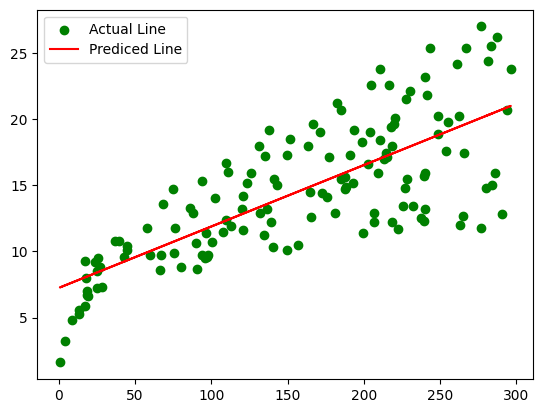

In [333]:

plt.scatter(X_train,Y_train, color = 'green', label = 'Actual Line')
plt.plot(X_train,Y_train_pred, color = 'red', label = 'Prediced Line')
plt.legend()
plt.show()

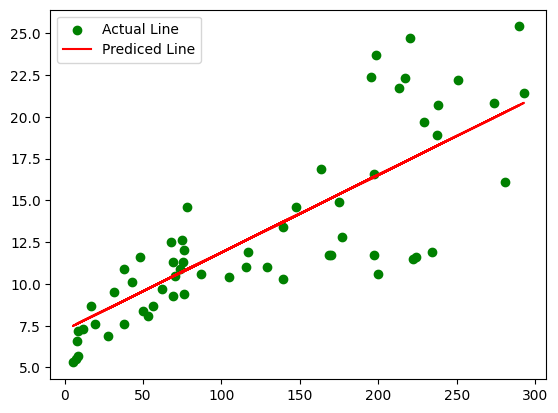

In [334]:

plt.scatter(X_test,Y_test, color = 'green', label = 'Actual Line')
plt.plot(X_test,Y_test_pred, color = 'red', label = 'Prediced Line')
plt.legend()
plt.show()

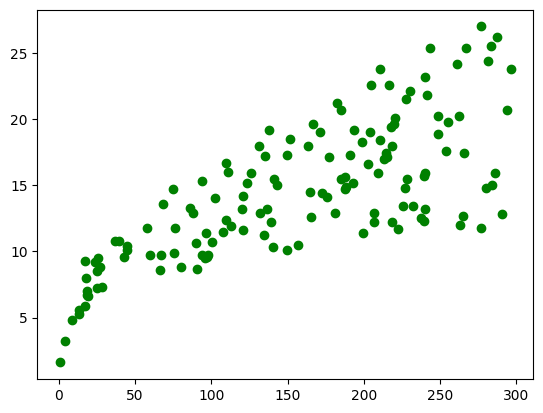

In [335]:
plt.scatter(X_train,Y_train, color = 'green')

In [336]:
pd.DataFrame([Y_train_pred,Y_test_pred]).transpose()

,0,1
0,20.433198,14.817854
1,15.820262,16.307544
2,12.478901,20.832305
3,8.343966,7.782431
4,20.730208,17.463099
...,...,...
135,8.399655,NaN
136,16.711292,NaN
137,17.342438,NaN
138,14.924592,NaN


In [337]:
from sklearn.metrics import r2_score,mean_squared_error

print (r2_score(Y_test,Y_test_pred)) # actual data with the preditction data

0.6714477229302764


In [348]:
# IF YOU INCLUDE THE BIAS IS TRUE THEN IT WILL TAKE ONLY ONE SINGLE COLUMN WITH THE DEGREE ZERO WHERE ADDITIONAL ONE COLUMN WILL ADD WITH THE VALUES 1
from sklearn.preprocessing import PolynomialFeatures
poly_features =PolynomialFeatures(degree=5, include_bias=True)
# poly_features.fit(X_train)
x_poly_train = poly_features.fit_transform(X_train)
x_poly_test = poly_features.fit_transform(X_test)

In [349]:
pd.DataFrame(x_poly_train).head()

,0,1,2,3,4,5
0,1.0,284.3,80826.49,2.297897e+07,6.532921e+09,1.857310e+12
1,1.0,184.9,34188.01,6.321363e+06,1.168820e+09,2.161148e+11
2,1.0,112.9,12746.41,1.439070e+06,1.624710e+08,1.834297e+10
3,1.0,23.8,566.44,1.348127e+04,3.208543e+05,7.636332e+06
4,1.0,290.7,84506.49,2.456604e+07,7.141347e+09,2.075990e+12


In [350]:
liner_poly_reg = LinearRegression()
liner_poly_reg

LinearRegression()

In [351]:
liner_poly_reg.fit(x_poly_train,Y_train)

LinearRegression()

In [352]:
print ('Coefficient is:', liner_poly_reg.coef_)
print ('Intercept is:', liner_poly_reg.intercept_)

Coefficient is: [ 0.00000000e+00  3.22417487e-01 -4.89112143e-03  3.83173292e-05
 -1.35719736e-07  1.76100134e-10]
Intercept is: 2.493486926972988


In [353]:
y_test_poly_pred = liner_poly_reg.predict(x_poly_test)
y_train_poly_pred = liner_poly_reg.predict(x_poly_train)

In [354]:
pd.DataFrame([y_train_poly_pred,y_test_poly_pred]).transpose()

,0,1
0,19.743492,15.510303
1,16.534425,16.925908
2,12.871172,20.886551
3,7.870861,5.655091
4,20.553989,17.526675
...,...,...
135,8.044386,NaN
136,17.187025,NaN
137,17.483524,NaN
138,15.630035,NaN


In [355]:
print(f'r2_score for test is : {r2_score(Y_test,y_test_poly_pred)*100:.4f}')
print(f'r2_score for train is : {r2_score(Y_train,y_train_poly_pred)*100:.4f}')

r2_score for test is : 65.5112
r2_score for train is : 60.2191


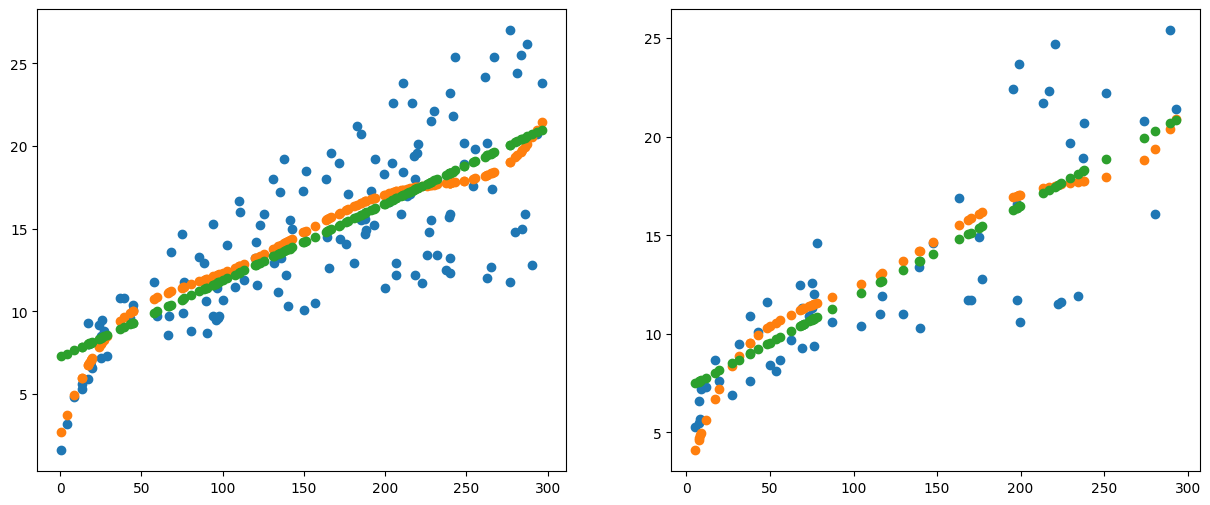

In [346]:
plt.figure(figsize = (15,6))
plt.subplot(1,2,1)
plt.scatter(X_train,Y_train, label = 'Actuals')
plt.scatter(X_train,y_train_poly_pred)
plt.scatter(X_train,Y_train_pred)

plt.subplot(1,2,2)
plt.scatter(X_test,Y_test, label = 'Actuals')
plt.scatter(X_test,y_test_poly_pred)
plt.scatter(X_test,Y_test_pred)
plt.show()

In [347]:
print (f'Mean Squared error is : {mean_squared_error(Y_test,y_test_poly_pred):.4f}')
print (f'Mean Squared error is : {mean_squared_error(Y_train,y_train_poly_pred):.4f}')

Mean Squared error is : 9.4171
Mean Squared error is : 10.4389
